# 00 - Pre-Data Exploration

Initial profile and schema inspection of raw datasets in `datasets/`:
- `7k_books.csv`
- `google_books_dataset.csv`
- `nepali_books_clean.csv`
- `comic_books_10000_dataset.csv` (analyzed for suitability/exclusion)


In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
import pandas as pd

from app.config import DATASETS_DIR

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.2f}".format)

## Helper

In [2]:
def null_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return per-column null count and null % for a dataframe."""
    nulls = df.isnull().sum()
    pct = (nulls / len(df) * 100).round(2)
    return pd.DataFrame({"null_count": nulls, "null_%": pct}).sort_values("null_%", ascending=False)

---
# Dataset 1 — `7k_books.csv`

## Shape & columns

In [3]:
books_7k = pd.read_csv(DATASETS_DIR / "7k_books.csv", dtype={"isbn13": "string", "isbn10": "string"})
print(f"Shape : {books_7k.shape[0]:,} rows x {books_7k.shape[1]} columns")
print(f"Columns: {list(books_7k.columns)}")

Shape : 6,810 rows x 12 columns
Columns: ['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']


## dtypes

In [4]:
books_7k.dtypes.to_frame("dtype")

,dtype
isbn13,string
isbn10,string
title,str
subtitle,str
authors,str
categories,str
thumbnail,str
description,str
published_year,float64
average_rating,float64


## Null / missing values

In [5]:
null_summary(books_7k)

,null_count,null_%
subtitle,4429,65.04
thumbnail,329,4.83
description,262,3.85
categories,99,1.45
authors,72,1.06
average_rating,43,0.63
num_pages,43,0.63
ratings_count,43,0.63
published_year,6,0.09
isbn13,0,0.00


## Sample rows

In [6]:
books_7k.head(5)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCPgAACAAJ&printsec=frontcover&im...,A NOVEL THAT READERS and critics have been eagerly anticipating for over a d...,2004.00,3.85,247.00,361.00
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GPgAACAAJ&printsec=frontcover&im...,A new 'Christie for Christmas' -- a full-length novel adapted from her accla...,2000.00,3.83,241.00,5164.00
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQawwEACAAJ&printsec=frontcover&im...,Volume Two of Stephen Donaldson's acclaimed second trilogy featuing the comp...,1982.00,3.97,479.00,172.00
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2TgANz74C&printsec=frontcover&im...,"A memorable, mesmerizing heroine Jennifer -- brilliant, beautiful, an attorn...",1993.00,3.93,512.00,29532.00
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5XsFcpGIC&printsec=frontcover&im...,Lewis' work on the nature of love divides love into four categories; Affecti...,2002.00,4.15,170.00,33684.00


## Numeric statistics

In [7]:
books_7k.describe(include="number")

,published_year,average_rating,num_pages,ratings_count
count,6804.00,6767.00,6767.00,6767.00
mean,1998.63,3.93,348.18,21069.10
std,10.48,0.33,242.38,137620.68
min,1853.00,0.00,0.00,0.00
25%,1996.00,3.77,208.00,159.00
50%,2002.00,3.96,304.00,1018.00
75%,2005.00,4.13,420.00,5992.50
max,2019.00,5.00,3342.00,5629932.00


## Top categories

In [8]:
books_7k["categories"].value_counts().head(20).to_frame("count")

,count
categories,
Fiction,2588
Juvenile Fiction,538
Biography & Autobiography,401
History,264
Literary Criticism,166
Philosophy,160
Comics & Graphic Novels,159
Religion,137
Drama,132


## Published year distribution

In [9]:
books_7k["published_year"].value_counts().sort_index().tail(30).to_frame("count")

,count
published_year,
1989.00,82
1990.00,95
1991.00,106
1992.00,128
1993.00,118
1994.00,147
1995.00,149
1996.00,181
1997.00,190


## Average rating distribution

<Axes: >

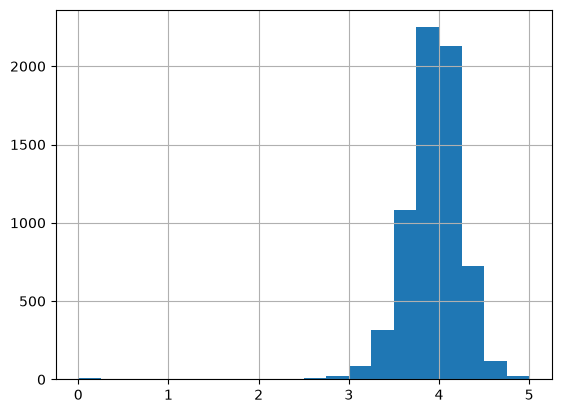

In [10]:
books_7k["average_rating"].hist(bins=20)

## ISBN-13 uniqueness

In [11]:
total = len(books_7k)
unique_isbn = books_7k["isbn13"].nunique()
print(f"Total rows      : {total:,}")
print(f"Unique isbn13   : {unique_isbn:,}")
print(f"Duplicate isbn13: {total - unique_isbn:,}")

Total rows      : 6,810
Unique isbn13   : 6,810
Duplicate isbn13: 0


---
# Dataset 2 — `google_books_dataset.csv`

## Shape & columns

In [12]:
google = pd.read_csv(DATASETS_DIR / "google_books_dataset.csv", dtype={"isbn_13": "string", "isbn_10": "string"}, low_memory=False)
print(f"Shape : {google.shape[0]:,} rows x {google.shape[1]} columns")
print(f"Columns: {list(google.columns)}")

Shape : 15,147 rows x 21 columns
Columns: ['book_id', 'title', 'subtitle', 'authors', 'publisher', 'published_date', 'description', 'page_count', 'categories', 'average_rating', 'ratings_count', 'language', 'preview_link', 'info_link', 'isbn_13', 'isbn_10', 'list_price', 'currency', 'buyable', 'search_category', 'thumbnail']


## dtypes

In [13]:
google.dtypes.to_frame("dtype")

,dtype
book_id,str
title,str
subtitle,str
authors,str
publisher,str
published_date,str
description,str
page_count,float64
categories,str
average_rating,float64


## Null / missing values

In [14]:
null_summary(google)

,null_count,null_%
average_rating,14290,94.34
list_price,12204,80.57
currency,12204,80.57
subtitle,9164,60.50
publisher,8057,53.19
isbn_10,8026,52.99
isbn_13,7764,51.26
description,6796,44.87
authors,3525,23.27
categories,2452,16.19


## Sample rows

In [15]:
google.head(5)

,book_id,title,subtitle,authors,publisher,published_date,description,page_count,categories,average_rating,ratings_count,language,preview_link,info_link,isbn_13,isbn_10,list_price,currency,buyable,search_category,thumbnail
0,LR_VDQAAQBAJ,Bestsellers,"The Path (bestsellers, free bestsellers, bestsellers for women, bestsellers ...","Ivan King, bestsellers",bestsellers,2017-01-04,"Hear What the Critics are Saying ""Wow, what an Amazing Book for young adults...",70.00,Young Adult Fiction,NaN,0,en,http://books.google.com/books?id=LR_VDQAAQBAJ&printsec=frontcover&dq=fiction...,https://play.google.com/store/books/details?id=LR_VDQAAQBAJ&source=gbs_api,<NA>,<NA>,12.99,USD,True,fiction bestsellers,http://books.google.com/books/content?id=LR_VDQAAQBAJ&printsec=frontcover&im...
1,WcjTDQAAQBAJ,Bestsellers,"Hell: A Place Without Hope (bestseller books, bestseller books free, bestsel...","Ivan King, bestsellers",bestsellers,2017-01-03,"Hear What the Critics are Saying Wow, very inspirational and powerful; every...",32.00,Comics & Graphic Novels,NaN,0,en,http://books.google.com/books?id=WcjTDQAAQBAJ&pg=PT31&dq=fiction+bestsellers...,https://play.google.com/store/books/details?id=WcjTDQAAQBAJ&source=gbs_api,<NA>,<NA>,9.99,USD,True,fiction bestsellers,http://books.google.com/books/content?id=WcjTDQAAQBAJ&printsec=frontcover&im...
2,4fXUDAAAQBAJ,The Bestseller Code,Anatomy of the Blockbuster Novel,"Jodie Archer, Matthew L. Jockers",Macmillan,2016-09-20,"""What if there was an algorithm that could predict which novels become mega-...",253.00,Business & Economics,NaN,0,en,http://books.google.com/books?id=4fXUDAAAQBAJ&printsec=frontcover&dq=fiction...,http://books.google.com/books?id=4fXUDAAAQBAJ&dq=fiction+bestsellers&hl=&sou...,9781250088277,1250088275,NaN,NaN,False,fiction bestsellers,http://books.google.com/books/content?id=4fXUDAAAQBAJ&printsec=frontcover&im...
3,yIVuDwAAQBAJ,Bestseller,A Century of America's Favorite Books,Robert McParland,Bloomsbury Publishing PLC,2018-12-15,"Whether curled up on a sofa with a good mystery, lounging by the pool with a...",335.00,Literary Criticism,NaN,0,en,http://books.google.com/books?id=yIVuDwAAQBAJ&pg=PA277&dq=fiction+bestseller...,https://play.google.com/store/books/details?id=yIVuDwAAQBAJ&source=gbs_api,9781538110003,1538110008,40.50,USD,True,fiction bestsellers,http://books.google.com/books/content?id=yIVuDwAAQBAJ&printsec=frontcover&im...
4,2JHXwAEACAAJ,Bestsellers: Popular Fiction since 1900,NaN,C. Bloom,Palgrave Macmillan,2002-07-09,"This guide and reference work of all of the bestselling books, authors and g...",306.00,Literary Criticism,NaN,0,en,http://books.google.com/books?id=2JHXwAEACAAJ&dq=fiction+bestsellers&hl=&cd=...,http://books.google.com/books?id=2JHXwAEACAAJ&dq=fiction+bestsellers&hl=&sou...,9780333687420,0333687426,NaN,NaN,False,fiction bestsellers,http://books.google.com/books/content?id=2JHXwAEACAAJ&printsec=frontcover&im...


## Numeric statistics

In [16]:
google.describe(include="number")

,page_count,average_rating,ratings_count,list_price
count,14933.00,857.00,15147.00,2943.00
mean,484.79,4.05,0.38,48.17
std,438.48,1.11,9.27,81.43
min,0.00,1.00,0.00,0.00
25%,205.00,3.50,0.00,9.98
50%,368.00,4.00,0.00,19.00
75%,658.00,5.00,0.00,58.00
max,7768.00,5.00,826.00,1755.00


## Column name differences vs canonical schema

In [17]:
canonical = ["isbn13", "title", "authors", "categories", "description",
             "published_year", "average_rating", "num_pages", "ratings_count", "thumbnail"]
google_cols = list(google.columns)

mapping = {
    "isbn_13"       : "isbn13",
    "page_count"    : "num_pages",
    "published_date": "published_year  (needs .dt.year extraction)",
}
print("Columns requiring rename / transform to reach canonical schema:")
for raw, canon in mapping.items():
    present = raw in google_cols
    print(f"  {raw:20s}  ->  {canon}  (present={present})")

extra = set(google_cols) - set(canonical) - set(mapping.keys())
print(f"\nExtra columns not in canonical schema: {sorted(extra)}")

Columns requiring rename / transform to reach canonical schema:
  isbn_13               ->  isbn13  (present=True)
  page_count            ->  num_pages  (present=True)
  published_date        ->  published_year  (needs .dt.year extraction)  (present=True)

Extra columns not in canonical schema: ['book_id', 'buyable', 'currency', 'info_link', 'isbn_10', 'language', 'list_price', 'preview_link', 'publisher', 'search_category', 'subtitle']


## `published_date` sample values

In [18]:
google["published_date"].dropna().head(10).to_frame()

,published_date
0,2017-01-04
1,2017-01-03
2,2016-09-20
3,2018-12-15
4,2002-07-09
5,2015-01-01
6,1984
7,1996-10-21
8,2011-08
9,1925


## Top categories

In [19]:
google["categories"].value_counts().head(20).to_frame("count")

,count
categories,
Fiction,994
Computers,737
Business & Economics,563
Education,371
History,365
Cooking,309
Medical,254
Science,252
Literary Criticism,250


## Language distribution

In [20]:
google["language"].value_counts().head(15).to_frame("count")

,count
language,
en,14821
es,69
de,42
fr,35
pt-BR,34
it,22
zh-CN,18
nl,12
id,9


## Average rating distribution

<Axes: >

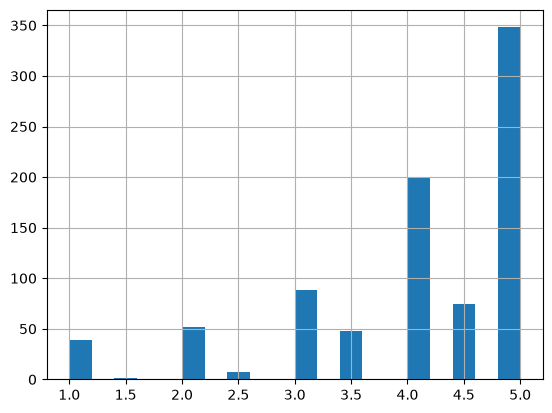

In [21]:
google["average_rating"].hist(bins=20)

## ISBN-13 uniqueness

In [22]:
total = len(google)
unique_isbn = google["isbn_13"].nunique()
print(f"Total rows       : {total:,}")
print(f"Unique isbn_13   : {unique_isbn:,}")
print(f"Duplicate isbn_13: {total - unique_isbn:,}")

Total rows       : 15,147
Unique isbn_13   : 7,377
Duplicate isbn_13: 7,770


---
# Dataset 3 — `nepali_books_clean.csv`

## Shape & columns

In [23]:
nepali = pd.read_csv(DATASETS_DIR / "nepali_books_clean.csv", dtype={"isbn13": "string"})
print(f"Shape : {nepali.shape[0]:,} rows x {nepali.shape[1]} columns")
print(f"Columns: {list(nepali.columns)}")

Shape : 2,495 rows x 9 columns
Columns: ['isbn13', 'title', 'authors', 'categories', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']


## dtypes

In [24]:
nepali.dtypes.to_frame("dtype")

,dtype
isbn13,string
title,str
authors,str
categories,str
description,str
published_year,int64
average_rating,float64
num_pages,int64
ratings_count,int64


## Null / missing values

In [25]:
null_summary(nepali)

,null_count,null_%
isbn13,1398,56.03
title,0,0.00
authors,0,0.00
categories,0,0.00
description,0,0.00
published_year,0,0.00
average_rating,0,0.00
num_pages,0,0.00
ratings_count,0,0.00


## Sample rows

In [26]:
nepali.head(5)

,isbn13,title,authors,categories,description,published_year,average_rating,num_pages,ratings_count
0,9788185693941.0,Munā-Madana,Laxmi Prasad Devkota,Nepali Literature,"One of the most admired works in Nepali literature, Muna madan is an episod...",1979,5.00,60,3
1,<NA>,Shakuntala,Laxmi Prasad Devkota,Nepali Literature,"Narrative poem on Śakuntalā, a character from the Mahābhārata.",1991,0.00,122,0
2,<NA>,Lakshmī nibandha-saṅgraha,Laxmi Prasad Devkota,Nepali Literature,A Nepali literary work titled 'Lakshmī nibandha-saṅgraha' by Laxmi Prasad ...,1983,0.00,238,0
3,9780231050142.0,"Nepali visions, Nepali dreams",Laxmi Prasad Devkota,Nepali Literature,"A Nepali literary work titled 'Nepali visions, Nepali dreams' by Laxmi Prasa...",1980,0.00,170,0
4,<NA>,Lakshmī kathā saṅgraha,Laxmi Prasad Devkota,Nepali Literature,A Nepali literary work titled 'Lakshmī kathā saṅgraha' by Laxmi Prasad De...,1975,0.00,165,0


## Numeric statistics

In [27]:
nepali.describe(include="number")

,published_year,average_rating,num_pages,ratings_count
count,2495.00,2495.00,2495.00,2495.00
mean,1995.88,0.05,181.56,0.03
std,18.09,0.46,169.51,0.33
min,1841.00,0.00,0.00,0.00
25%,1985.00,0.00,77.50,0.00
50%,2000.00,0.00,144.00,0.00
75%,2009.00,0.00,240.00,0.00
max,2074.00,5.00,2213.00,9.00


## Column alignment with canonical schema

In [28]:
canonical = ["isbn13", "title", "authors", "categories", "description",
             "published_year", "average_rating", "num_pages", "ratings_count", "thumbnail"]
nepali_cols = set(nepali.columns)

present = [c for c in canonical if c in nepali_cols]
missing = [c for c in canonical if c not in nepali_cols]
extra   = [c for c in nepali_cols if c not in canonical]

print(f"Present in canonical  : {present}")
print(f"Missing from canonical: {missing}  <- filled with NA by loader")
print(f"Extra columns         : {extra}")

Present in canonical  : ['isbn13', 'title', 'authors', 'categories', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']
Missing from canonical: ['thumbnail']  <- filled with NA by loader
Extra columns         : []


## Top categories

In [29]:
nepali["categories"].value_counts().head(20).to_frame("count")

,count
categories,
Nepali Literature,2495


## Published year distribution

In [30]:
nepali["published_year"].value_counts().sort_index().to_frame("count")

,count
published_year,
1841,1
1879,1
1893,1
1900,6
1904,1
...,...
2023,5
2024,3
2025,8


## ISBN-13 uniqueness

In [31]:
total = len(nepali)
unique_isbn = nepali["isbn13"].nunique()
print(f"Total rows      : {total:,}")
print(f"Unique isbn13   : {unique_isbn:,}")
print(f"Duplicate isbn13: {total - unique_isbn:,}")

Total rows      : 2,495
Unique isbn13   : 1,064
Duplicate isbn13: 1,431


---
# Dataset 4 — `comic_books_10000_dataset.csv`

## Shape & columns

In [32]:
comics = pd.read_csv(DATASETS_DIR / "comic_books_10000_dataset.csv")
print(f"Shape : {comics.shape[0]:,} rows x {comics.shape[1]} columns")
print(f"Columns: {list(comics.columns)}")

Shape : 10,000 rows x 17 columns
Columns: ['comic_id', 'Title', 'Writer', 'Artist', 'Studio/Publisher', 'Release Year', 'Format', 'Theme (Color Style)', 'Genre', 'Country of Origin', 'Page Count', 'Rating (out of 10)', 'Status', 'Language', 'Age Rating', 'Awards', 'Volume Count']


## dtypes

In [33]:
comics.dtypes.to_frame("dtype")

,dtype
comic_id,str
Title,str
Writer,str
Artist,str
Studio/Publisher,str
Release Year,int64
Format,str
Theme (Color Style),str
Genre,str
Country of Origin,str


## Null / missing values

In [34]:
null_summary(comics)

,null_count,null_%
Awards,6016,60.16
comic_id,0,0.00
Country of Origin,0,0.00
Age Rating,0,0.00
Language,0,0.00
Status,0,0.00
Rating (out of 10),0,0.00
Page Count,0,0.00
Genre,0,0.00
Title,0,0.00


## Sample rows

In [35]:
comics.head(5)

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.00,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.30,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.80,Ongoing,English,Teen+,Japan Media Arts Award Winner,13
3,CMC-00004,Abyss Destiny,Yuna Yamaguchi,Yuna Yamaguchi,Kodansha (Kodansha USA),2014,Manga Volume,Black & White,Slice of Life / Drama,Japan,592,8.70,Cancelled,Japanese,Teen+,Eisner Award Nominee,13
4,CMC-00005,After Smoke,Shannon Watters,Warren Ellis,Kodansha Comics,2005,OGN,Black & White,Romance / Drama,USA,2465,7.00,Ongoing,English,Mature,NaN,4


## Numeric statistics

In [36]:
comics.describe(include="number")

,Release Year,Page Count,Rating (out of 10),Volume Count
count,10000.00,10000.00,10000.00,10000.00
mean,2015.50,2232.87,8.06,13.67
std,7.44,1866.72,0.53,11.36
min,2000.00,48.00,6.00,1.00
25%,2010.00,748.75,7.70,5.00
50%,2017.00,1571.00,8.10,10.00
75%,2022.00,3511.00,8.40,19.00
max,2026.00,14400.00,9.90,56.00


## Column overlap with canonical schema

In [37]:
canonical = ["isbn13", "title", "authors", "categories", "description",
             "published_year", "average_rating", "num_pages", "ratings_count", "thumbnail"]
comics_lower = {c.lower() for c in comics.columns}

overlap = [c for c in canonical if c in comics_lower]
missing = [c for c in canonical if c not in comics_lower]
extra   = sorted(set(comics.columns) - {c.title() for c in overlap})

print(f"Canonical cols present : {overlap}")
print(f"Missing from canonical : {missing}")
print(f"Extra comic-specific   : {extra}")

Canonical cols present : ['title']
Missing from canonical : ['isbn13', 'authors', 'categories', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count', 'thumbnail']
Extra comic-specific   : ['Age Rating', 'Artist', 'Awards', 'Country of Origin', 'Format', 'Genre', 'Language', 'Page Count', 'Rating (out of 10)', 'Release Year', 'Status', 'Studio/Publisher', 'Theme (Color Style)', 'Volume Count', 'Writer', 'comic_id']


## Genre distribution

In [38]:
comics["Genre"].value_counts().head(20).to_frame("count")

,count
Genre,
Horror / Supernatural,295
Sports / Action,255
School / Romance,250
Comedy / Slice of Life,242
Mystery / Thriller,230
Superhero / Psychological,224
Superhero / Political,215
Superhero / Thriller,213
Romance / Drama,213


## Status distribution

In [39]:
comics["Status"].value_counts().to_frame("count")

,count
Status,
Completed,5005
Ongoing,3820
Hiatus,741
Cancelled,434


## Age rating distribution

In [40]:
comics["Age Rating"].value_counts().to_frame("count")

,count
Age Rating,
Teen+,3996
Mature,3367
Young Adult,1326
All Ages,819
Mature 17+,492


## Country of Origin distribution

In [41]:
comics["Country of Origin"].value_counts().head(15).to_frame("count")

,count
Country of Origin,
Japan,3575
USA,3150
South Korea,897
China,550
UK,266
Canada,233
New Zealand,228
Australia,212
South Korea / Japan,188


## Rating distribution

<Axes: >

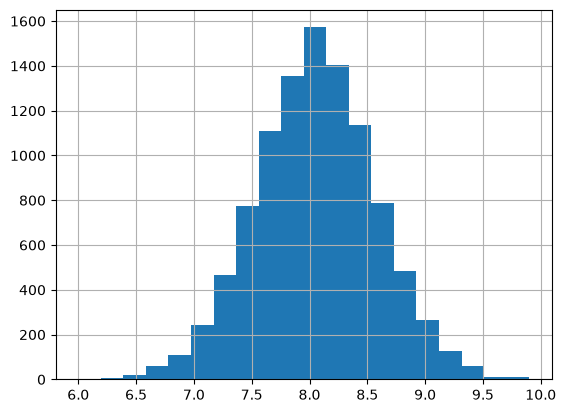

In [42]:
pd.to_numeric(comics["Rating (out of 10)"], errors="coerce").hist(bins=20)

## Why this dataset is excluded from notebook 01

In [43]:
# comic_books_10000_dataset.csv is in datasets/ but NOT ingested in notebook 01.
# Reasons visible from the exploration above:
#   - No isbn13 column              -> cannot dedup by ISBN
#   - No description column         -> nothing to embed for semantic search
#   - No thumbnail column           -> no cover image
#   - Rating scale is 0-10 (not 0-5) -> needs rescaling before merging
#   - Schema is comic-specific      -> Format, Theme, Studio/Publisher, Volume Count
print("Excluded from ingestion. Missing canonical fields: isbn13, description, thumbnail")
print("Rating scale: 0-10  (catalog uses 0-5)")

Excluded from ingestion. Missing canonical fields: isbn13, description, thumbnail
Rating scale: 0-10  (catalog uses 0-5)


---
# Cross-dataset Summary

## Row counts per source

In [44]:
pd.DataFrame([
    {"source": "7k_books.csv",                 "rows": len(books_7k), "columns": len(books_7k.columns), "ingested": True},
    {"source": "google_books_dataset.csv",      "rows": len(google),   "columns": len(google.columns),   "ingested": True},
    {"source": "nepali_books_clean.csv",        "rows": len(nepali),   "columns": len(nepali.columns),   "ingested": True},
    {"source": "comic_books_10000_dataset.csv", "rows": len(comics),   "columns": len(comics.columns),   "ingested": False},
])

,source,rows,columns,ingested
0,7k_books.csv,6810,12,True
1,google_books_dataset.csv,15147,21,True
2,nepali_books_clean.csv,2495,9,True
3,comic_books_10000_dataset.csv,10000,17,False
